# 04 — Refusal as MNAR: a sensitivity sweep

Model C treats don't-know as ignorable (MAR given covariates) but lets **refused**
be missing-not-at-random. We cannot estimate the refusal mechanism from BRFSS alone
— it is **not identified** — so we do not pretend to. Instead we sweep a single,
interpretable sensitivity parameter and report how the gradient responds.

**The parameter.** We tilt refusers' conditional income distribution by `exp(γ·I)`,
which shifts their mean *log*-income by `Δ = γ·σ²` relative to what their covariates
predict. We sweep `Δ` directly:

- `Δ = 0` → refusers look like the MAR population (ignorable; model C at γ=0).
- `Δ > 0` → refusers earn more than their covariates predict (the conventional
  "high-income people refuse" story; Tourangeau & Yan 2007).
- `Δ < 0` → refusers earn less (the MIHA pattern: the most vulnerable are missing).

We sweep `Δ` from log(½) to log(2) — refusers earning anywhere from half to double
their covariate-predicted income — a deliberately wide range.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recode as rc
import income_model as im
import survey as sv

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')
frame = pd.read_parquet(os.path.join(DERIVED, 'brfss_2023_analysis.parquet'))
d, colnames, strata = rc.frame_to_recoded(frame)

K = 32
income = im.fit_grouped_lognormal(d.X[d.mask('bracket')], d.log_lo[d.mask('bracket')],
                                  d.log_hi[d.mask('bracket')], d.w[d.mask('bracket')])
sigma2 = income.sigma ** 2
print(f'income model sigma = {income.sigma:.3f}  (sigma^2 = {sigma2:.3f})')

rA = im.fit_A(d)
rB = im.fit_B(d, K=K, income=income)
print(f'A (midpoint)  OR/doubling = {rA.or_per_doubling:.4f}')
print(f'B (grouped)   OR/doubling = {rB.or_per_doubling:.4f}')

income model sigma = 0.692  (sigma^2 = 0.478)


A (midpoint)  OR/doubling = 0.8526
B (grouped)   OR/doubling = 0.8364


## Sweep the refusal-selection parameter

For each assumed shift `Δ` in refusers' mean log-income we refit model C (income
model fixed) and attach a design-based linearized SE at each point.

In [2]:
deltas = np.linspace(np.log(0.5), np.log(2.0), 13)   # refusers earn 0.5x .. 2x
rows = []
t0 = time.time()
for delta in deltas:
    gamma = delta / sigma2
    rC = im.fit_C(d, gamma=gamma, K=K, income=income)
    use, nodes = im.latent_nodes(d, income, K, gamma=gamma, two_mechanism=True)
    se = sv.linearized_se(rC.outcome.params, d.X[use], d.y[use], d.w[use],
                          nodes, strata[use]) * im.LN2
    rows.append({'delta': delta, 'income_ratio': np.exp(delta), 'gamma': gamma,
                 'log_or': rC.log_or_per_doubling, 'se': se, 'or': rC.or_per_doubling})
sweep = pd.DataFrame(rows)
sweep['or_lo'] = np.exp(sweep['log_or'] - 1.96 * sweep['se'])
sweep['or_hi'] = np.exp(sweep['log_or'] + 1.96 * sweep['se'])
print(f'swept {len(deltas)} points in {time.time()-t0:.1f}s')
sweep[['income_ratio', 'gamma', 'or', 'or_lo', 'or_hi']].round(4)

swept 13 points in 210.8s


,income_ratio,gamma,or,or_lo,or_hi
0,0.5000,-1.4488,0.8684,0.8485,0.8888
1,0.5612,-1.2073,0.8621,0.8420,0.8826
2,0.6300,-0.9659,0.8560,0.8358,0.8767
3,0.7071,-0.7244,0.8504,0.8301,0.8712
4,0.7937,-0.4829,0.8453,0.8250,0.8661
5,0.8909,-0.2415,0.8408,0.8205,0.8616
6,1.0000,0.0000,0.8369,0.8166,0.8576
7,1.1225,0.2415,0.8336,0.8135,0.8543
8,1.2599,0.4829,0.8310,0.8110,0.8515
9,1.4142,0.7244,0.8291,0.8092,0.8494


## Confirm the central anchor with the design bootstrap

The linearized band holds the income model fixed; we confirm the MAR anchor (γ=0)
with the full stratified bootstrap (warm-started), which refits income and outcome
models together. Agreement validates the linearized band across the sweep.

In [3]:
B_ANCHOR = 40
anchor_ci = {}
for delta in [0.0]:
    g = delta / sigma2
    full = im.fit_C(d, gamma=g, K=K, income=income)
    fitters = {'C': (lambda gg: (lambda dd: im.fit_C(
        dd, gamma=gg, K=24, income_init=(income.beta, income.sigma),
        outcome_init=full.outcome.params)))(g)}
    ci = sv.bootstrap_gradients(d, strata, fitters, B=B_ANCHOR, seed=7,
                                points={'C': full.log_or_per_doubling})['C']
    anchor_ci[round(delta, 3)] = ci
    print(f'  Δ=log({np.exp(delta):.2f})  OR={np.exp(ci.point):.4f}  '
          f'boot 95% CI [{np.exp(ci.lo):.4f}, {np.exp(ci.hi):.4f}]')

  Δ=log(1.00)  OR=0.8369  boot 95% CI [0.8145, 0.8597]


## The sensitivity curve

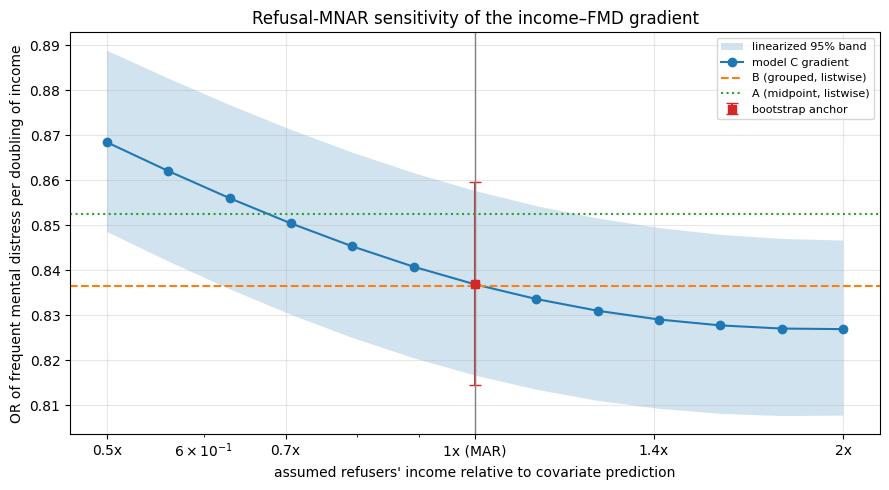

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(sweep['income_ratio'], sweep['or_lo'], sweep['or_hi'], alpha=0.2,
                label='linearized 95% band')
ax.plot(sweep['income_ratio'], sweep['or'], '-o', label='model C gradient')
for delta, ci in anchor_ci.items():
    r = np.exp(delta)
    ax.errorbar([r], [np.exp(ci.point)],
                yerr=[[np.exp(ci.point) - np.exp(ci.lo)], [np.exp(ci.hi) - np.exp(ci.point)]],
                fmt='s', color='C3', capsize=4,
                label='bootstrap anchor' if delta == 0.0 else None)
ax.axhline(rB.or_per_doubling, color='C1', ls='--', label='B (grouped, listwise)')
ax.axhline(rA.or_per_doubling, color='C2', ls=':', label='A (midpoint, listwise)')
ax.axvline(1.0, color='gray', lw=1)
ax.set_xscale('log'); ax.set_xticks([0.5, 0.7, 1.0, 1.4, 2.0])
ax.set_xticklabels(['0.5x', '0.7x', '1x (MAR)', '1.4x', '2x'])
ax.set_xlabel("assumed refusers' income relative to covariate prediction")
ax.set_ylabel('OR of frequent mental distress per doubling of income')
ax.set_title('Refusal-MNAR sensitivity of the income–FMD gradient')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
sweep.to_csv(os.path.join(DERIVED, 'brfss_income_mnar_sweep.csv'), index=False)

## What would it take to change the conclusion?

In [5]:
or_min, or_max = sweep['or'].min(), sweep['or'].max()
print(f"model B gradient (OR/doubling):      {rB.or_per_doubling:.4f}")
print(f"model C gradient across the sweep:   {or_min:.4f} to {or_max:.4f}")
print(f"  (at refusers earning {sweep.loc[sweep['or'].idxmin(),'income_ratio']:.2f}x "
      f"to {sweep.loc[sweep['or'].idxmax(),'income_ratio']:.2f}x predicted)")
span = 100 * (or_max - or_min) / rB.or_per_doubling
print(f"\nTotal sensitivity span = {span:.1f}% of the B gradient across a 0.5x-2x "
      f"refusal-income assumption.")

model B gradient (OR/doubling):      0.8364
model C gradient across the sweep:   0.8269 to 0.8684
  (at refusers earning 2.00x to 0.50x predicted)

Total sensitivity span = 5.0% of the B gradient across a 0.5x-2x refusal-income assumption.
